# 🎧 Music Taste Predictor & Recommender — Training & EDA Walkthrough

This notebook trains and compares the same models `src/train.py` trains from the
command line, but interactively — with exploratory data analysis and side-by-side
model comparison charts. It runs on **`music_dataset.csv`** (1,200 tracks, 8 genres,
40 artists) but nothing here is hard-coded to this file: `src/schema.py` auto-detects
the genre / artist / track / feature columns from whatever CSV you point it at.

**Pipeline:** load data → EDA → auto-detect schema → train & compare KNN / Random
Forest / Gradient Boosting / XGBoost / Ensemble → save the best genre & artist models
→ train the KNN song recommender → save everything for `app.py` (the Streamlit app).


In [1]:
import sys
sys.path.insert(0, ".")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.data_loader import load_config, load_dataset, clean_target_column
from src.schema import detect_schema, summarize_schema
from src.models import build_model_pipeline, AVAILABLE_MODELS
from src.recommender import SongRecommender
from src.evaluate import classification_report_dict

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_PATH = "music_dataset.csv"
config = load_config("config.yaml")
df = load_dataset(DATA_PATH)
print(df.shape)
df.head()


(1200, 16)


,track_id,song_name,artist_name,genre,energy,danceability,valence,tempo,acousticness,loudness,instrumentalness,duration_sec,duration_display,popularity,explicit,key_signature
0,trk_00000,Yeh Parwaaz Ke Paar,Nucleya,Rock,0.836896,0.296476,0.637855,138.800690,0.000000,-4.609739,0.109838,249,4:09,76,No,C
1,trk_00001,Woh Parwaaz Ki Roshni,Yuvan Shankar Raja,R&B,0.593084,0.704331,0.458757,105.492095,0.160673,-9.757015,0.320767,228,3:48,84,No,E
2,trk_00002,Yeh Rangeen Ki Chaahat,Atif Aslam,Electronic,0.758108,0.671823,0.795182,101.187050,0.091107,-6.385215,0.355171,190,3:10,40,No,G
3,trk_00003,Mera Sapno Ka Safar,Shreya Ghoshal,Jazz,0.336539,0.549575,0.516772,109.746110,0.586157,-12.032240,0.666018,223,3:43,59,Yes,A
4,trk_00004,Woh Manzil Ke Sang,Vishal-Shekhar,Pop,0.717664,0.754760,0.523299,117.103044,0.244673,-5.991061,0.408913,162,2:42,27,No,D


## 1. Exploratory data analysis

In [2]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,1200,1200,trk_00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
song_name,1200,1200,Yeh Parwaaz Ke Paar,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_name,1200,40,Vishal-Shekhar,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,1200,8,Pop,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,1200.0,NaN,NaN,NaN,0.662384,0.206183,0.064059,0.534751,0.704562,0.81201,1.0
danceability,1200.0,NaN,NaN,NaN,0.627838,0.183792,0.079709,0.502499,0.652475,0.766791,1.0
valence,1200.0,NaN,NaN,NaN,0.57327,0.154138,0.08266,0.465824,0.576753,0.683363,1.0
tempo,1200.0,NaN,NaN,NaN,111.24526,17.288181,63.193889,97.986954,112.831114,124.730524,154.153936
acousticness,1200.0,NaN,NaN,NaN,0.248675,0.257263,0.0,0.072048,0.163801,0.305339,1.0
loudness,1200.0,NaN,NaN,NaN,-7.011223,3.663433,-20.349841,-8.171989,-6.199207,-4.58996,-0.220138


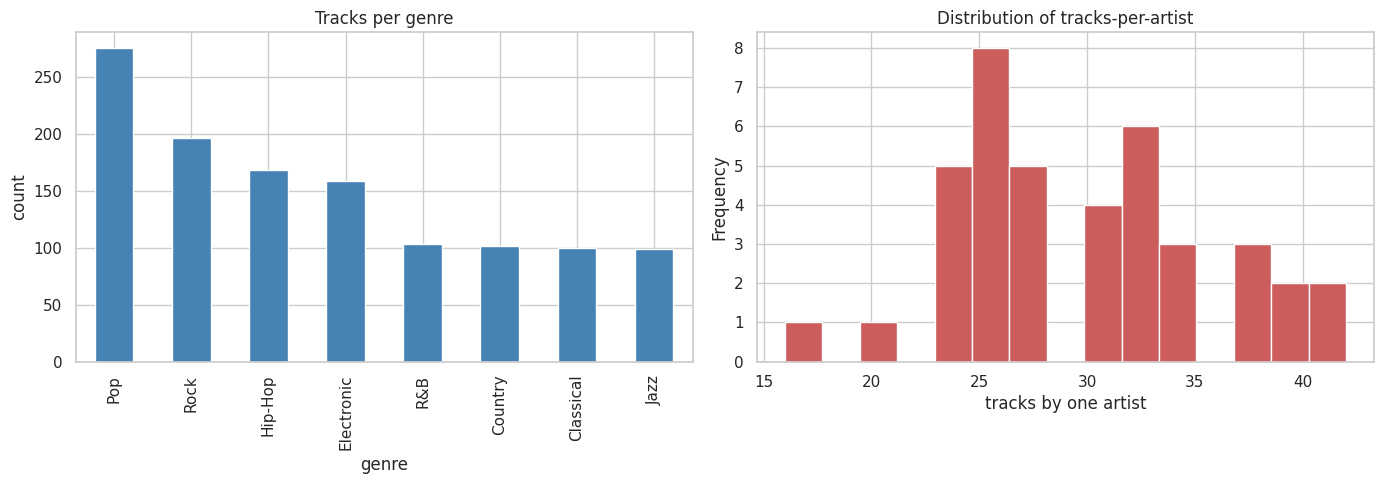

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["genre"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Tracks per genre")
axes[0].set_ylabel("count")

df["artist_name"].value_counts().plot(kind="hist", bins=15, ax=axes[1], color="indianred")
axes[1].set_title("Distribution of tracks-per-artist")
axes[1].set_xlabel("tracks by one artist")
plt.tight_layout()
plt.show()


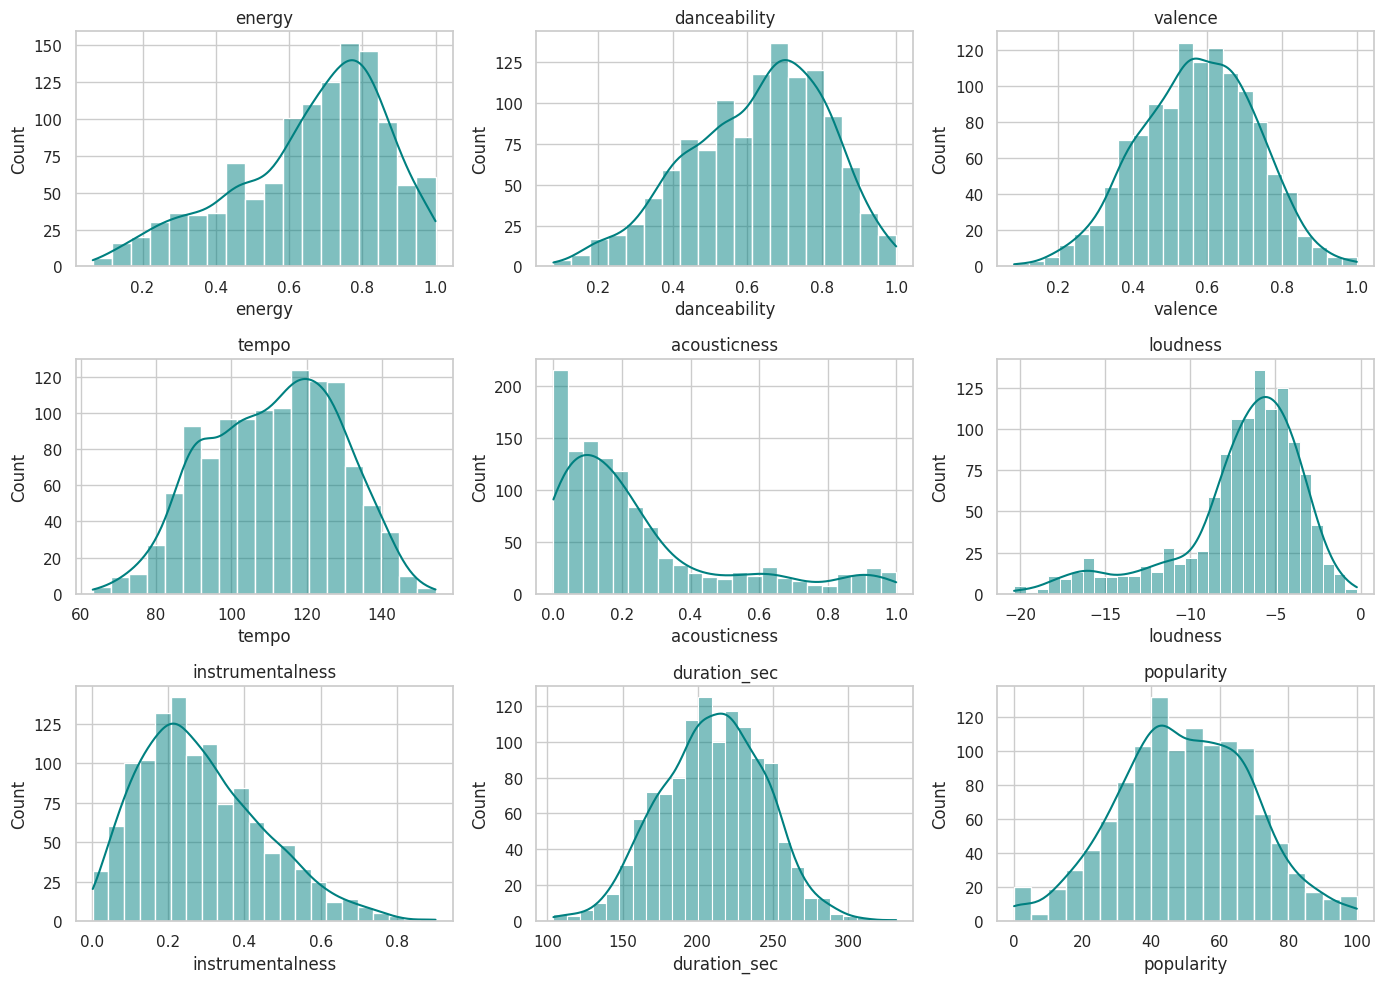

In [4]:
numeric_cols = ["energy", "danceability", "valence", "tempo", "acousticness",
                "loudness", "instrumentalness", "duration_sec", "popularity"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()


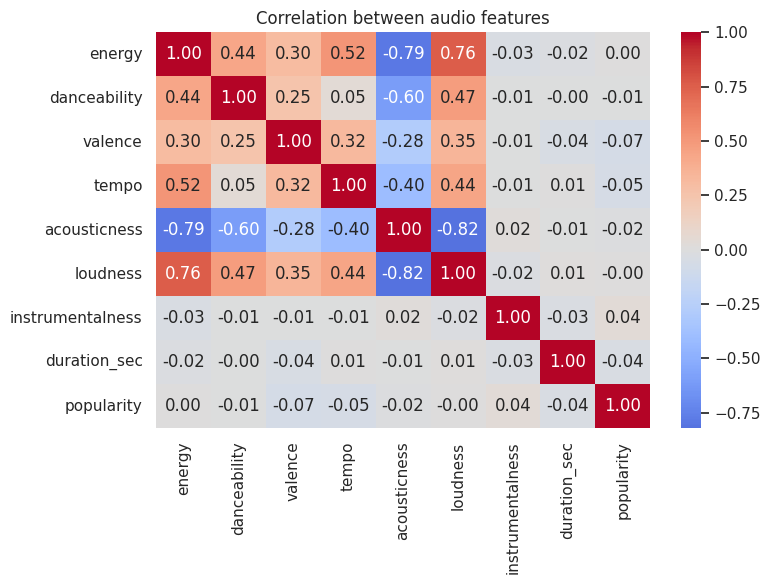

In [5]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between audio features")
plt.tight_layout()
plt.show()


**Sanity check — is artist predictable from audio features at all?**
Below we check whether any artist in this dataset concentrates in one genre. If artists
are spread roughly evenly across genres (which they are here), no amount of modeling on
audio features alone will predict artist identity well — that's a property of the
dataset, not the model. This directly explains the low artist-model accuracy in
section 4.

In [6]:
artist_genre = pd.crosstab(df["artist_name"], df["genre"])
dominant_share = artist_genre.div(artist_genre.sum(axis=1), axis=0).max(axis=1)
print("Share of an artist's tracks in their single most common genre:")
print(dominant_share.describe())
print()
print(f"Chance-level accuracy for {df['artist_name'].nunique()}-way artist classification: "
      f"{1/df['artist_name'].nunique():.1%}")


Share of an artist's tracks in their single most common genre:
count    40.000000
mean      0.259419
std       0.051032
min       0.181818
25%       0.224910
50%       0.250000
75%       0.281429
max       0.428571
dtype: float64

Chance-level accuracy for 40-way artist classification: 2.5%


## 2. Auto-detect the schema

No hard-coded column names — this works whether the dataset uses `genre`, `Category`, `track_genre`, etc. (see `config.yaml` to extend the candidate lists for unusual column names).

In [7]:
schema = detect_schema(df, config)
print(summarize_schema(schema))
feature_num, feature_cat = schema["numeric_features"], schema["categorical_features"]


Detected dataset schema:
  Genre column      : genre
  Artist column     : artist_name
  Track column      : song_name
  User column       : None
  Numeric features  : ['energy', 'danceability', 'valence', 'tempo', 'acousticness', 'loudness', 'instrumentalness', 'duration_sec', 'popularity']
  Categorical feats : ['explicit', 'key_signature']


## 3. Train & compare all five classifiers on **genre**

In [8]:
target_col = schema["genre_col"]
clean_df = clean_target_column(df, target_col, config["training"]["min_class_count"])

X = clean_df[feature_num + feature_cat]
y_raw = clean_df[target_col].astype(str)
genre_encoder = LabelEncoder()
y = genre_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config["training"]["test_size"],
    random_state=config["training"]["random_state"], stratify=y,
)

genre_results = {}
for model_type in AVAILABLE_MODELS:
    pipe = build_model_pipeline(model_type, feature_num, feature_cat, config)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    metrics = classification_report_dict(y_test, y_pred, y_proba, classes=np.unique(y))
    genre_results[model_type] = {"pipeline": pipe, **metrics}
    print(f"{model_type:>10s}: {metrics}")


       knn: {'accuracy': 0.7792, 'f1_macro': 0.7904, 'f1_weighted': 0.7795, 'n_test_samples': 240, 'n_classes': 8, 'top_3_accuracy': 0.9917}


   bagging: {'accuracy': 0.8792, 'f1_macro': 0.888, 'f1_weighted': 0.8774, 'n_test_samples': 240, 'n_classes': 8, 'top_3_accuracy': 1.0}


  boosting: {'accuracy': 0.8542, 'f1_macro': 0.8715, 'f1_weighted': 0.854, 'n_test_samples': 240, 'n_classes': 8, 'top_3_accuracy': 0.9917}


   xgboost: {'accuracy': 0.8375, 'f1_macro': 0.8537, 'f1_weighted': 0.8365, 'n_test_samples': 240, 'n_classes': 8, 'top_3_accuracy': 1.0}


  ensemble: {'accuracy': 0.8625, 'f1_macro': 0.8827, 'f1_weighted': 0.8618, 'n_test_samples': 240, 'n_classes': 8, 'top_3_accuracy': 0.9958}


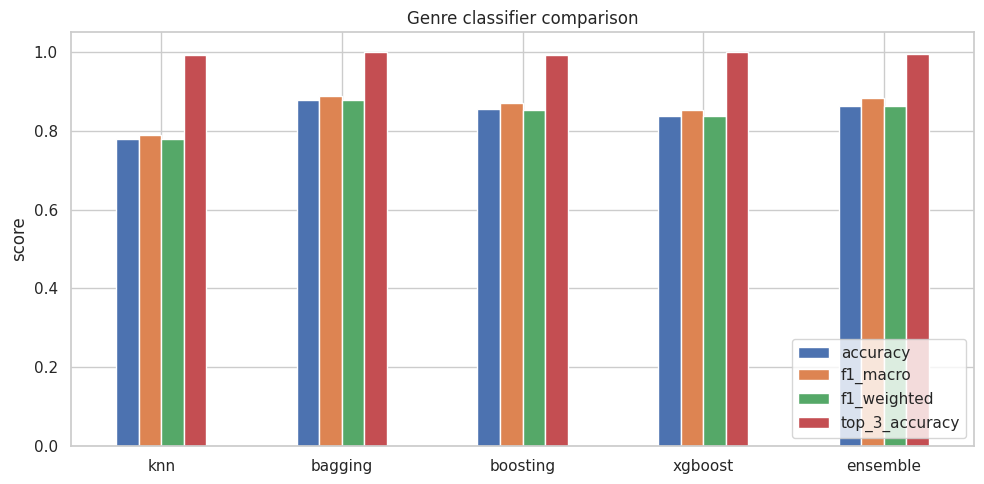

,accuracy,f1_macro,f1_weighted,n_test_samples,n_classes,top_3_accuracy
knn,0.7792,0.7904,0.7795,240.0,8.0,0.9917
bagging,0.8792,0.8880,0.8774,240.0,8.0,1.0000
boosting,0.8542,0.8715,0.8540,240.0,8.0,0.9917
xgboost,0.8375,0.8537,0.8365,240.0,8.0,1.0000
ensemble,0.8625,0.8827,0.8618,240.0,8.0,0.9958


In [9]:
genre_metrics_df = pd.DataFrame({m: {k: v for k, v in r.items() if k != "pipeline"}
                                  for m, r in genre_results.items()}).T
genre_metrics_df[["accuracy", "f1_macro", "f1_weighted", "top_3_accuracy"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1.05)
)
plt.title("Genre classifier comparison")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
genre_metrics_df


## 4. Save the best genre model

In [10]:
BEST_GENRE_MODEL = max(genre_results, key=lambda m: genre_results[m]["accuracy"])
print("Best genre model:", BEST_GENRE_MODEL)

final_genre_pipeline = build_model_pipeline(BEST_GENRE_MODEL, feature_num, feature_cat, config)
final_genre_pipeline.fit(X, y)   # refit on ALL data for the saved artifact
joblib.dump({"pipeline": final_genre_pipeline, "encoder": genre_encoder},
            f"{BEST_GENRE_MODEL}_genre_predictor.pkl")
print(f"Saved {BEST_GENRE_MODEL}_genre_predictor.pkl")


Best genre model: bagging


Saved bagging_genre_predictor.pkl


## 5. Train & compare classifiers on **artist**

**Expectation-setting:** as shown in the EDA above, artists in this dataset are spread
roughly evenly across genres and audio-feature ranges, so no model can push accuracy
far past the ~2.5% chance baseline (1-in-40) using audio features alone. We still train
and save it — it's a legitimate (if weak) baseline — but treat this as a demonstration
of the *pipeline*, not a claim that artist is well-predicted here. Real artist-ID
systems use vocal/production embeddings or listening co-occurrence data, not track-level
audio stats.

In [11]:
target_col = schema["artist_col"]
clean_df = clean_target_column(df, target_col, config["training"]["min_class_count"])

X = clean_df[feature_num + feature_cat]
y_raw = clean_df[target_col].astype(str)
artist_encoder = LabelEncoder()
y = artist_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config["training"]["test_size"],
    random_state=config["training"]["random_state"], stratify=y,
)

artist_results = {}
for model_type in AVAILABLE_MODELS:
    pipe = build_model_pipeline(model_type, feature_num, feature_cat, config)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    metrics = classification_report_dict(y_test, y_pred, y_proba, classes=np.unique(y))
    artist_results[model_type] = {"pipeline": pipe, **metrics}
    print(f"{model_type:>10s}: {metrics}")


       knn: {'accuracy': 0.0167, 'f1_macro': 0.0127, 'f1_weighted': 0.0157, 'n_test_samples': 240, 'n_classes': 40, 'top_3_accuracy': 0.0542}


   bagging: {'accuracy': 0.0208, 'f1_macro': 0.0128, 'f1_weighted': 0.0162, 'n_test_samples': 240, 'n_classes': 40, 'top_3_accuracy': 0.0625}


  boosting: {'accuracy': 0.0292, 'f1_macro': 0.0181, 'f1_weighted': 0.0228, 'n_test_samples': 240, 'n_classes': 40, 'top_3_accuracy': 0.075}


   xgboost: {'accuracy': 0.0208, 'f1_macro': 0.018, 'f1_weighted': 0.0195, 'n_test_samples': 240, 'n_classes': 40, 'top_3_accuracy': 0.0708}


  ensemble: {'accuracy': 0.0208, 'f1_macro': 0.0172, 'f1_weighted': 0.0184, 'n_test_samples': 240, 'n_classes': 40, 'top_3_accuracy': 0.0542}


In [12]:
BEST_ARTIST_MODEL = max(artist_results, key=lambda m: artist_results[m]["accuracy"])
print("Best artist model:", BEST_ARTIST_MODEL,
      f"(accuracy {artist_results[BEST_ARTIST_MODEL]['accuracy']:.1%}, "
      f"chance level {1/len(artist_encoder.classes_):.1%})")

final_artist_pipeline = build_model_pipeline(BEST_ARTIST_MODEL, feature_num, feature_cat, config)
final_artist_pipeline.fit(X, y)
joblib.dump({"pipeline": final_artist_pipeline, "encoder": artist_encoder},
            f"{BEST_ARTIST_MODEL}_artist_predictor.pkl")
print(f"Saved {BEST_ARTIST_MODEL}_artist_predictor.pkl")


Best artist model: boosting (accuracy 2.9%, chance level 2.5%)


Saved boosting_artist_predictor.pkl


## 6. Train the KNN song recommender

This is a similarity/retrieval task (song is near-unique per row), so it's handled separately from the classifiers above via `NearestNeighbors` over the same feature space.

In [13]:
recommender = SongRecommender(
    numeric_features=feature_num,
    categorical_features=feature_cat,
    track_col=schema["track_col"],
    artist_col=schema["artist_col"],
    genre_col=schema["genre_col"],
    config=config,
)
recommender.fit(df)
joblib.dump(recommender, "knn_recommender.pkl")

# demo: recommend songs similar to a "high energy, danceable, Pop-leaning" profile
demo_prefs = {"energy": 0.85, "danceability": 0.8, "valence": 0.7, "tempo": 128}
recommender.recommend_from_preferences(demo_prefs, top_n=10)


,song_name,artist_name,genre,energy,danceability,valence,similarity_score
0,Woh Saathiya Ka Rang,Monali Thakur,Electronic,0.748889,0.865321,0.667269,0.908531
1,Woh Tanha Ke Paar,Raftaar,Rock,0.776274,0.727769,0.768289,0.901792
2,Woh Silsila Ki Baarish,Alka Yagnik,Pop,0.873746,0.907834,0.805439,0.889313
3,Woh Rangeen Ki Baarish,Kavita Seth,Electronic,0.838842,0.764000,0.741276,0.845950
4,Mera Saathiya Waale,AP Dhillon,Pop,0.869779,0.874471,0.848235,0.829206
5,Woh Safar Ki Chaahat,Arijit Singh,Electronic,0.843595,0.786738,0.576924,0.821626
6,Woh Bekhayali Ki Raahein,Mohit Chauhan,Pop,0.830519,0.628103,0.693805,0.821024
7,Woh Tanha Ke Geet,Ritviz,Pop,0.953833,0.696670,0.769203,0.812648
8,Woh Chaand Ka Safar,Sonu Nigam,Electronic,0.797548,0.613680,0.711951,0.810770
9,Woh Silsila Ki Kahani,Divine,Pop,0.697371,0.900582,0.859622,0.801317


## 7. Save schema + metrics (used by `app.py`)

In [14]:
joblib.dump(schema, "schema.pkl")

metrics_all = {
    "genre": {k: v for k, v in genre_results[BEST_GENRE_MODEL].items() if k != "pipeline"},
    "artist": {k: v for k, v in artist_results[BEST_ARTIST_MODEL].items() if k != "pipeline"},
}
with open("metrics.json", "w") as f:
    json.dump(metrics_all, f, indent=2)

metrics_all


{'genre': {'accuracy': 0.8792,
  'f1_macro': 0.888,
  'f1_weighted': 0.8774,
  'n_test_samples': 240,
  'n_classes': 8,
  'top_3_accuracy': 1.0},
 'artist': {'accuracy': 0.0292,
  'f1_macro': 0.0181,
  'f1_weighted': 0.0228,
  'n_test_samples': 240,
  'n_classes': 40,
  'top_3_accuracy': 0.075}}

## 8. Next step — run the Streamlit app

```bash
streamlit run app.py
```

Then open the local URL Streamlit prints (typically http://localhost:8501). The app
auto-loads whichever `*_genre_predictor.pkl` / `*_artist_predictor.pkl` /
`knn_recommender.pkl` files this notebook just saved, so re-running this notebook with
a different dataset (edit `DATA_PATH` in cell 2) and reloading the app is all it takes
to swap in a new model — no code changes required.

**Deploying:** push this repo (including the `.pkl` files, `schema.pkl`,
`metrics.json`, and `music_dataset.csv`) to GitHub, then create a new app at
[share.streamlit.io](https://share.streamlit.io) pointing at `app.py`.
